In [1]:
import model
import os
from option import args
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import data
import utils
import numpy as np
import json
import h5py
loaded = {}
loaded_gt ={}

path,tot = "",""


def load_path(base_dir,ids):
    base_dir_7t = [base_dir + "/HCP_7T/" + i   for i in ids]
    base_dir_3t = [base_dir + "/HCP_3T/" + i   for i in ids]
    path_7t = {}
    path_3t = {}
    for i in base_dir_7t:
        path_7t[i[-6:]] = {"h5" : i + "/" + i[-6:] + ".h5"
                        , "GT" : i + "/" + i[-6:] + "_GT.h5"}
    for i in base_dir_3t:
        path_3t[i[-6:]] = {"h5" : i + "/" + i[-6:] + ".h5"
                        , "upsampled" : i + "/" + i[-6:] + "_upsampled.h5"
                        , "GT" : i + "/" + i[-6:] + "_GT.h5"}
    path = {'3T': path_3t, "7T":  path_7t}
    p = list(path_7t.keys())
    q = list(path_3t.keys())
    common = list(set(p) & set(q))

    return path,len(common)

def load_data(base_dir,ids):
    ids.sort()
    path,tot = load_path(base_dir,ids)
    act_ids = []
    for i in ids:
        name = path['3T'][i]['h5']
        if(not os.path.isfile(name)):
            continue
        res_vol = h5py.File(name, 'r')
        
        # print(res_vol.keys())
        loaded[i] = {'vol0':res_vol.get('volumes0')[:]
                            ,'mask':res_vol.get('mask')[:] }
        
        name = path['7T'][i]['GT']
        
        if(not os.path.isfile(name)):
            continue
        res = h5py.File(name, 'r')
        # print(res.keys())
        loaded_gt[i] = {'ADC':res.get('ADC')[:]
                            ,'FA':res.get('FA')[:] 
                            ,'color_FA':res.get('color_FA')[:] }
        
        
        res_vol.close()
        res.close()

        name = path['7T'][i]['h5']
        
        if(not os.path.isfile(name)):
            continue
        res = h5py.File(name, 'r')
        loaded_gt[i]['vol0'] = res.get('volumes0')[:]
        loaded_gt[i]['mask'] = res.get('mask')[:]
        res_vol.close()
        res.close()
        act_ids.append(i)
    return act_ids

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


number of common Subjects  171


In [2]:
load_dir = "working_models/good_models"

In [3]:
paths = {}
max_ep = 0
for i in os.listdir(load_dir):
    if "check" not in i and "tensor" not in i:
        temp = []
#         print(os.listdir(load_dir + "/" + i))
        for j in os.listdir(load_dir + "/" + i + "/model"):
            temp.append(load_dir + "/" + i + "/model/" + j)
            
            
            _,ep,hfen,psnr = j.split("_")
            ep = int(ep)
            if(max_ep < ep):
                latest_ep_path = load_dir + "/" + i + "/model/" + j
                max_ep = ep
                
            conf = load_dir + "/" + i + "/config.txt"
        paths[i] = (temp,conf,latest_ep_path) 

In [4]:
list_models = list(paths.keys())

In [5]:
# paths

In [6]:
paths[list_models[0]][2]

'working_models/good_models/dmri_rdn,3d,train_80,test_20,C,attn_False,growth64,loss_1*L1,bs_8,tvFalse/model/model_85_0.2709_23.0297.pt'

In [7]:
paths[list_models[0]][1]

'working_models/good_models/dmri_rdn,3d,train_80,test_20,C,attn_False,growth64,loss_1*L1,bs_8,tvFalse/config.txt'

In [8]:
list_models

['dmri_rdn,3d,train_80,test_20,C,attn_False,growth64,loss_1*L1,bs_8,tvFalse',
 'dmri_rdn,3d,train_80,test_20,C,attn_False,growth32,loss_1*L1,bs_8,tvFalse']

In [9]:
load_model = list_models[0]

In [10]:
load_model

'dmri_rdn,3d,train_80,test_20,C,attn_False,growth64,loss_1*L1,bs_8,tvFalse'

In [11]:
with open(paths[load_model][1], 'r') as f:
    args.__dict__ = json.load(f)

In [12]:
args

Namespace(block_size=[48, 48, 6], var_blk_size=False, start_var=True, epochs=100, dir='/storage', batch_size=8, sort=True, debug=False, preload=True, ret_points=False, enable_thres=True, thres=0.7, psnr_sim=22, rel_coord=False, patience=3, no_vols=80, test_vols=20, lr=0.0005, max_lr=0.01, lr_decay=20, decay_type='step', gamma=0.8, optimizer='ADAM', momentum=0.9, beta1=0.9, beta2=0.999, epsilon=1e-08, weight_decay=0, start_epoch=0, loss='1*L1', skip_threshold=100.0, run_name='dmri_rdn,3d,train_80,test_20,C,attn_False,growth64,loss_1*L1,bs_8,tvFalse', save='DTIArb', load='.', save_models=False, resume=0, print_every=20, save_every=30, cpu=False, gpu=0, seed=1, reset=False, pin_mem=False, model='dmri_rdn', in_chans=7, encoder='rdb', tv=False, attention=False, drop_prob=0, growth=64, type='3d', out_chans=5, RDNconfig='C', precision='single', cuda=True, scale=[1, 1, 1], offset=3, stable_epoch=1)

In [13]:
# import json
# with open(paths[list_models[0]][1], 'w') as f:
#     json.dump(args.__dict__, f, indent=2)

In [14]:
curr_model = model.Model(args)
curr_model.load(paths[load_model][2])

Making model... here
load from model_working_models/good_models/dmri_rdn,3d,train_80,test_20,C,attn_False,growth64,loss_1*L1,bs_8,tvFalse/model/model_85_0.2709_23.0297.pt.pt


In [15]:
ids = utils.get_ids()
ids.sort()
offset = 100
args.no_vols = 1
args.test_vols = 20
total_vols = args.no_vols+args.test_vols
temp = ids[offset:offset+args.no_vols]
temp.extend(ids[offset:args.test_vols+offset])
ids = temp
args.batch_size = 1
print(ids)

['352738', '352738', '360030', '365343', '380036', '381038', '385046', '389357', '393247', '395756', '397760', '401422', '406836', '412528', '429040', '436845', '463040', '467351', '525541', '541943', '547046']


### Dataloader

In [25]:
loader = data.Data(args,ids= ids)

Loading Done


In [32]:
len(loader.testing_dataset)

1196

In [168]:
def make_pos_encoding(blk,size): 
    
    blk_x1,blk_x2,blk_y1,blk_y2,blk_z1,blk_z2 = blk
    blk_x2 = blk_x1 + size[0]-1
    blk_y2 = blk_y1 + size[1]-1
    blk_z2 = blk_z1 + size[2]-1
    res = []
    t = []
    for i in range(blk_x1,blk_x2+1):
        l = []
        for j in range(blk_y1,blk_y2+1):
            q = []
            for k in range(blk_z1,blk_z2+1):
                q.append((i,j,k))   
            l.append(q)
        t.append(l)
    res.append(t)
    res = torch.from_numpy(np.asarray(res))
    res = torch.permute(res, (0,4,1,2,3))
    res = res.squeeze()
    return res

def blk_from_coor(coor):
    blk = []
    for i in range(len(rel_coor)):
        blk.append(int(rel_coor[i].min().item()))
        blk.append(int(rel_coor[i].max().item()))
    return blk

def interpolate(inp,size):
    inp = torch.permute(inp, (3,0,1,2))
    inp = torch.unsqueeze(inp, 0)
    interpolated = torch.nn.functional.interpolate(inp,size = torch.Size(size))
    interpolated = torch.permute(interpolated, (2,3,4,1,0))
    return interpolated.squeeze()

def align(lr,hr,pred):
    lr,hr,pred = lr.cpu().detach().numpy(),hr.cpu().detach().numpy(),pred.cpu().detach().numpy()
    pos = lr.shape.index(min(lr.shape[:3]))
    if(pos == 1):
        lr = np.transpose(lr,(0,2,1,3))
        hr = np.transpose(hr,(0,2,1,3))
        pred = np.transpose(pred,(0,2,1,3))
    elif(pos == 0):
        lr = np.transpose(lr,(1,2,0,3))
        hr = np.transpose(hr,(1,2,0,3))
        pred = np.transpose(pred,(1,2,0,3))
    return lr,hr,pred
    

In [37]:
import utility
import skimage.metrics as metrics
from ssim_3d import ssim3D 

### TESTING

In [47]:
lr_hr = []
pred_hr = []

In [48]:
i

0

In [49]:
len(loader.testing_dataset[2])

6

In [106]:
ssim3D(hr_t,pred_t),ssim3D(hr_t,lr_t)

(tensor(0.8247), tensor(0.3136))

In [105]:
hr_t = torch.unsqueeze(torch.permute(torch.from_numpy(hr),(3,0,1,2)),0)
pred_t = torch.unsqueeze(torch.permute(torch.from_numpy(pred),(3,0,1,2)),0)
lr_t = torch.unsqueeze(torch.permute(torch.from_numpy(lr),(3,0,1,2)),0)

In [136]:
lr_hr = []
pred_hr = []
for i in range(10):
    
    lr, hr,_,rel_coor,out,inp_lr = loader.testing_dataset[i]
    
    lr_tensor = lr.squeeze().to('cuda').float()
    lr_tensor = torch.unsqueeze(lr_tensor, 0)
    rel_coor = rel_coor.squeeze().to('cuda').float()
    out = out.squeeze()
    hr = hr.squeeze()
    scale = [1.2,1.2,1.2]

    size = hr.shape[:3]
    rel_coor = make_pos_encoding(blk_from_coor(rel_coor),size).to('cuda').float()
    lr = torch.permute(lr_tensor, (0,4,1,2,3))
    
    pred = curr_model.forward(lr,size,rel_coor)
    
    pred = torch.permute(pred, (0,2,3,4,1)).float().squeeze()
    
    lr = interpolate(out,size)

    hr = interpolate(hr,size)
    
    hr_t = torch.unsqueeze(torch.permute(hr,(3,0,1,2)),0).cuda()
    pred_t = torch.unsqueeze(torch.permute(pred,(3,0,1,2)),0).cuda()
    lr_t = torch.unsqueeze(torch.permute(lr,(3,0,1,2)),0).cuda()
#     ssim = ssim3D(hr_t,pred_t).item()
    
    
    
    lr,hr,pred = align(lr,hr,pred)
    
    hfen = utility.hfen_metric(hr,lr)
    
    psnr = float(metrics.peak_signal_noise_ratio(hr,lr,data_range=1))
    
    ssim = ssim3D(hr_t,lr_t).item()
    
    lr_hr.append((hfen,psnr,ssim))
    
    hfen = utility.hfen_metric(hr,pred)
    
    psnr = float(metrics.peak_signal_noise_ratio(hr,pred,data_range=1))
    
    ssim = ssim3D(hr_t,pred_t).item()
    
    pred_hr.append((hfen,psnr,ssim))
#     break

In [137]:
lr_hr = np.asarray(lr_hr)
pred_hr = np.asarray(pred_hr)

In [138]:
pred_hr.shape,lr_hr.shape

((10, 3), (10, 3))

In [139]:
pred_hr,lr_hr

(array([[ 0.31189299, 25.01681901,  0.82473105],
        [ 0.25648487, 23.63115375,  0.80121309],
        [ 0.25341514, 23.05548503,  0.80149078],
        [ 0.22397979, 25.09673061,  0.80009902],
        [ 0.27286062, 22.42762105,  0.76586759],
        [ 0.27244976, 24.19526872,  0.8045916 ],
        [ 0.23607343, 23.05685534,  0.77890295],
        [ 0.28389096, 24.62987503,  0.81286335],
        [ 0.26675001, 24.75557435,  0.79948884],
        [ 0.20629118, 24.85484267,  0.80682719]]),
 array([[ 1.57503271, 15.58156292,  0.31362376],
        [ 1.30834544, 14.61595314,  0.26409784],
        [ 1.32283723, 14.13347493,  0.25195739],
        [ 1.11894155, 15.48146439,  0.38873681],
        [ 1.3661226 , 13.92001492,  0.20670919],
        [ 1.0626061 , 15.61558007,  0.37271667],
        [ 1.36755574, 14.4539724 ,  0.2042063 ],
        [ 1.12319171, 15.47673769,  0.36166549],
        [ 1.36967325, 15.76028768,  0.27758396],
        [ 1.04324138, 16.0268649 ,  0.40755573]]))

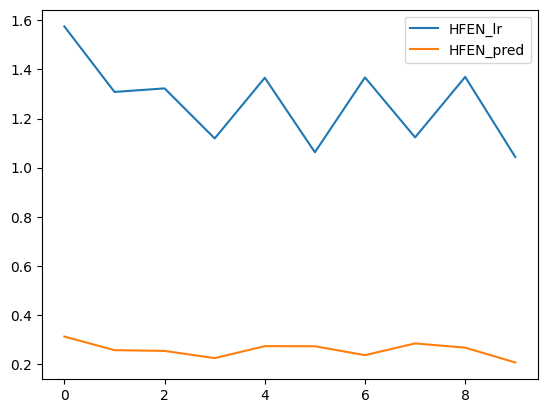

In [141]:
%matplotlib inline
plt.plot(lr_hr[:,0],label = 'HFEN_lr')
plt.plot(pred_hr[:,0],label = 'HFEN_pred')

plt.legend()

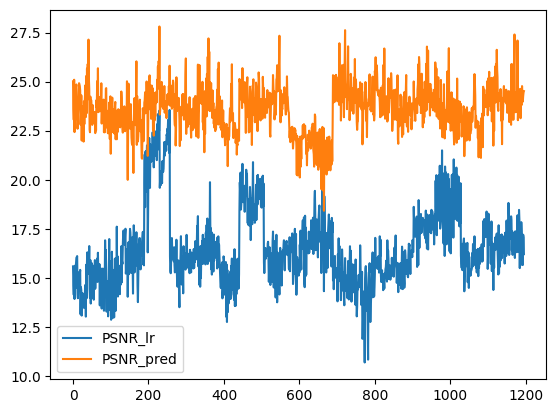

In [131]:
%matplotlib inline
plt.plot(lr_hr[:,1],label = 'PSNR_lr')
plt.plot(pred_hr[:,1],label = 'PSNR_pred')

plt.legend()

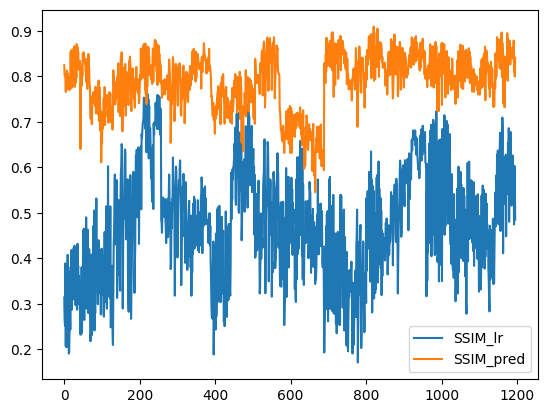

In [132]:
%matplotlib inline
plt.plot(lr_hr[:,2],label = 'SSIM_lr')
plt.plot(pred_hr[:,2],label = 'SSIM_pred')

plt.legend()

In [45]:
ids = utils.get_ids()
ids.sort()
offset = 100
args.no_vols = 1
args.test_vols = 50
total_vols = args.no_vols+args.test_vols
temp = ids[offset:offset+args.no_vols]
temp.extend(ids[offset:args.test_vols+offset])
ids = temp
args.batch_size = 1
print(ids)

['352738', '352738', '360030', '365343', '380036', '381038', '385046', '389357', '393247', '395756', '397760', '401422', '406836', '412528', '429040', '436845', '463040', '467351', '525541', '541943', '547046', '562345', '572045', '573249', '581450', '585256', '601127', '617748', '627549', '638049', '644246', '654552', '671855', '680957', '690152', '706040', '724446', '725751', '732243', '751550', '757764', '765864', '770352', '771354', '782561', '783462', '789373', '814649', '818859', '825048', '826353']


In [102]:
loader = data.Data(args,ids= ids[:2],patch_size = 30,data_config = [1.2,0,4])

Loading Done


In [103]:
loader.testing_dataset[0][0].shape,loader.testing_dataset[0][1].shape

(torch.Size([1, 33, 7, 27, 7]), (1, 53, 11, 43, 5))

In [104]:
len(loader.testing_dataset)

95

In [147]:
hr_dwi, hr_maps,_,rel_coor,lr_maps,lr_dwi = loader.testing_dataset[i]

In [148]:
hr_dwi.shape

torch.Size([1, 33, 7, 27, 7])

In [149]:
hr_maps.shape

(1, 53, 11, 43, 5)

In [150]:
lr_maps.shape

(1, 33, 7, 27, 5)

In [151]:
lr_dwi.shape

torch.Size([1, 33, 7, 27, 7])

In [158]:
hr_map.shape

(1, 53, 11, 43, 5)

In [160]:
hr_map.squeeze().shapeb


(53, 11, 43, 5)

In [164]:
hr_map

array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
   

### Inference on Validation Set

In [173]:
bi_maps = []
hr_maps = []
lr_maps = []
pred_maps = []

scores_bi = []
scores_pred = []
scale_buf = []
score_diff = []
hr_dwis = []


for i in range(len(loader.testing_dataset)):
    hr_dwi, hr_map,_,rel_coor,lr_map,lr_dwi = loader.testing_dataset[i]
    
    lr_tensor = lr_dwi.squeeze().to('cuda').float()
    lr_tensor = torch.unsqueeze(lr_tensor, 0)
    
    rel_coor = rel_coor.squeeze().to('cuda').float()
    
    lr_map = torch.from_numpy(lr_map.squeeze())
    hr_dwi = hr_dwi.squeeze()
    hr_map = torch.from_numpy(hr_map.squeeze())
    
    
    size = hr_map.shape[:3]
    rel_coor = make_pos_encoding(blk_from_coor(rel_coor),size).to('cuda').float()
    
    lr = torch.permute(lr_tensor, (0,4,1,2,3))
    
    pred = curr_model.forward(lr,size,rel_coor)
    
    pred_map = torch.permute(pred, (0,2,3,4,1)).float().squeeze()
    
    bi_map = interpolate(lr_map,size)

#     hr = interpolate(hr_map,size)
    
    
    hr_t = torch.unsqueeze(torch.permute(hr_map,(3,0,1,2)),0).cuda()
    pred_t = torch.unsqueeze(torch.permute(pred_map,(3,0,1,2)),0).cuda()
    bi_t = torch.unsqueeze(torch.permute(bi_map,(3,0,1,2)),0).cuda()
    
    _,_,pred_map = align(lr_map,hr_map,pred_map)
    
    lr_map,hr_map,bi_map = align(lr_map,hr_map,bi_map)
    
    
    hfen = utility.hfen_metric(hr_map,bi_map)
    psnr = float(metrics.peak_signal_noise_ratio(hr_map,bi_map,data_range=1))
    ssim = ssim3D(hr_t,bi_t).item()
    
    scores_bi.append((hfen,psnr,ssim))
    
    hfen = utility.hfen_metric(hr_map,pred_map)
    psnr = float(metrics.peak_signal_noise_ratio(hr_map,pred_map,data_range=1))
    ssim = ssim3D(hr_t,pred_t).item()
    
    scores_pred.append((hfen,psnr,ssim))
    
    score_diff.append([scores_pred[-1][i]-scores_bi[-1][i] for i in range(3)])
    
    bi_maps.append(bi_map)
    hr_maps.append(hr_map)
    lr_maps.append(lr_map)
    pred_maps.append(pred)
    
    scale_buf.append(size)
    hr_dwis.append(hr_dwi)
#     break
scores_lr = np.asarray(scores_lr)
scores_pred = np.asarray(scores_pred)
score_diff = np.asarray(score_diff)
    

OutOfMemoryError: CUDA out of memory. Tried to allocate 42.00 MiB. GPU 0 has a total capacty of 79.15 GiB of which 37.00 MiB is free. Process 2867428 has 3.34 GiB memory in use. Process 3088689 has 8.54 GiB memory in use. Process 3639955 has 492.00 MiB memory in use. Process 795034 has 66.73 GiB memory in use. Of the allocated memory 62.26 GiB is allocated by PyTorch, and 3.98 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [175]:

scores_lr = np.asarray(scores_lr)
scores_pred = np.asarray(scores_pred)
score_diff = np.asarray(score_diff)

In [176]:
%matplotlib inline
plt.plot(scores_lr[:,0],label = 'HFEN_lr')
plt.plot(scores_pred[:,0],label = 'HFEN_pred')

plt.legend()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [60]:
# lr_buf = []
# hr_buf = []
# pred_buf = []
# scores_lr = []
# scores_pred = []
# scale_buf = []

In [61]:
len(lr_buf)

35

In [153]:
i = 11

In [154]:
[round(scale_buf[i][j]/lr_maps[i].shape[j],1) for j in range(3)]

IndexError: index 11 is out of bounds for axis 0 with size 1

In [145]:
lr_maps[0].shape

(33, 27, 7, 5)

In [146]:
scale_buf[0]

(53, 11, 43)

In [99]:
lr_maps[i].shape

(30, 28, 8, 5)

In [100]:
scale_buf[i]

(36, 34, 10)

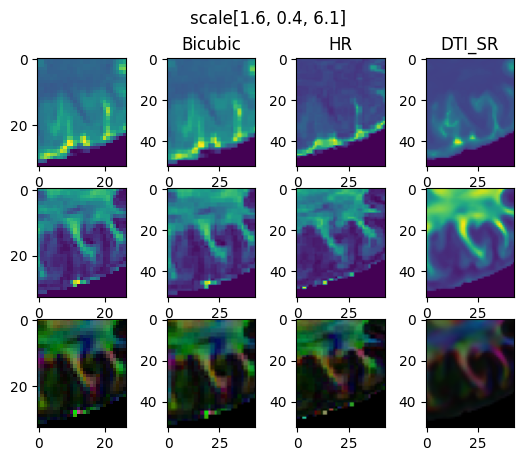

In [142]:
%matplotlib inline
fig,ax = plt.subplots(3,4)

fig.suptitle(f"scale{[round(scale_buf[i][j]/lr_maps[i].shape[j],1) for j in range(3)]}")

temp = lr_maps[i]
ax[0][0].imshow(temp[:,:,temp.shape[2]//2,0])
ax[1][0].imshow(temp[:,:,temp.shape[2]//2,1])
ax[2][0].imshow(temp[:,:,temp.shape[2]//2,2:])

temp = lr_buf[i]
ax[0][1].imshow(temp[:,:,temp.shape[2]//2,0])
ax[1][1].imshow(temp[:,:,temp.shape[2]//2,1])
ax[2][1].imshow(temp[:,:,temp.shape[2]//2,2:])

ax[0][1].set_title("Bicubic")
ax[0][2].set_title("HR")
ax[0][3].set_title("DTI_SR")

# ax[0][2].set_title("DTI_SR")


temp = hr_buf[i]
ax[0][2].imshow(temp[:,:,temp.shape[2]//2,0])
ax[1][2].imshow(temp[:,:,temp.shape[2]//2,1])
ax[2][2].imshow(temp[:,:,temp.shape[2]//2,2:])


temp = pred_buf[i]
ax[0][3].imshow(temp[:,:,temp.shape[2]//2,0])
ax[1][3].imshow(temp[:,:,temp.shape[2]//2,1])
ax[2][3].imshow(temp[:,:,temp.shape[2]//2,2:])

# plt.show()

In [54]:
print(scores_lr[i],scores_pred[i])

[ 1.12804627 15.48836653] [ 0.40096816 21.89015383]


In [59]:
min(scores_pred[:][0]),max(scores_pred[:][1]),min(scores_lr[:][0]),max(scores_lr[:][1])

(0.4799342751502991, 21.51728642491916, 1.6159651279449463, 14.077144943379604)

## ADC

RuntimeError: The size of tensor a (8) must match the size of tensor b (32) at non-singleton dimension 4

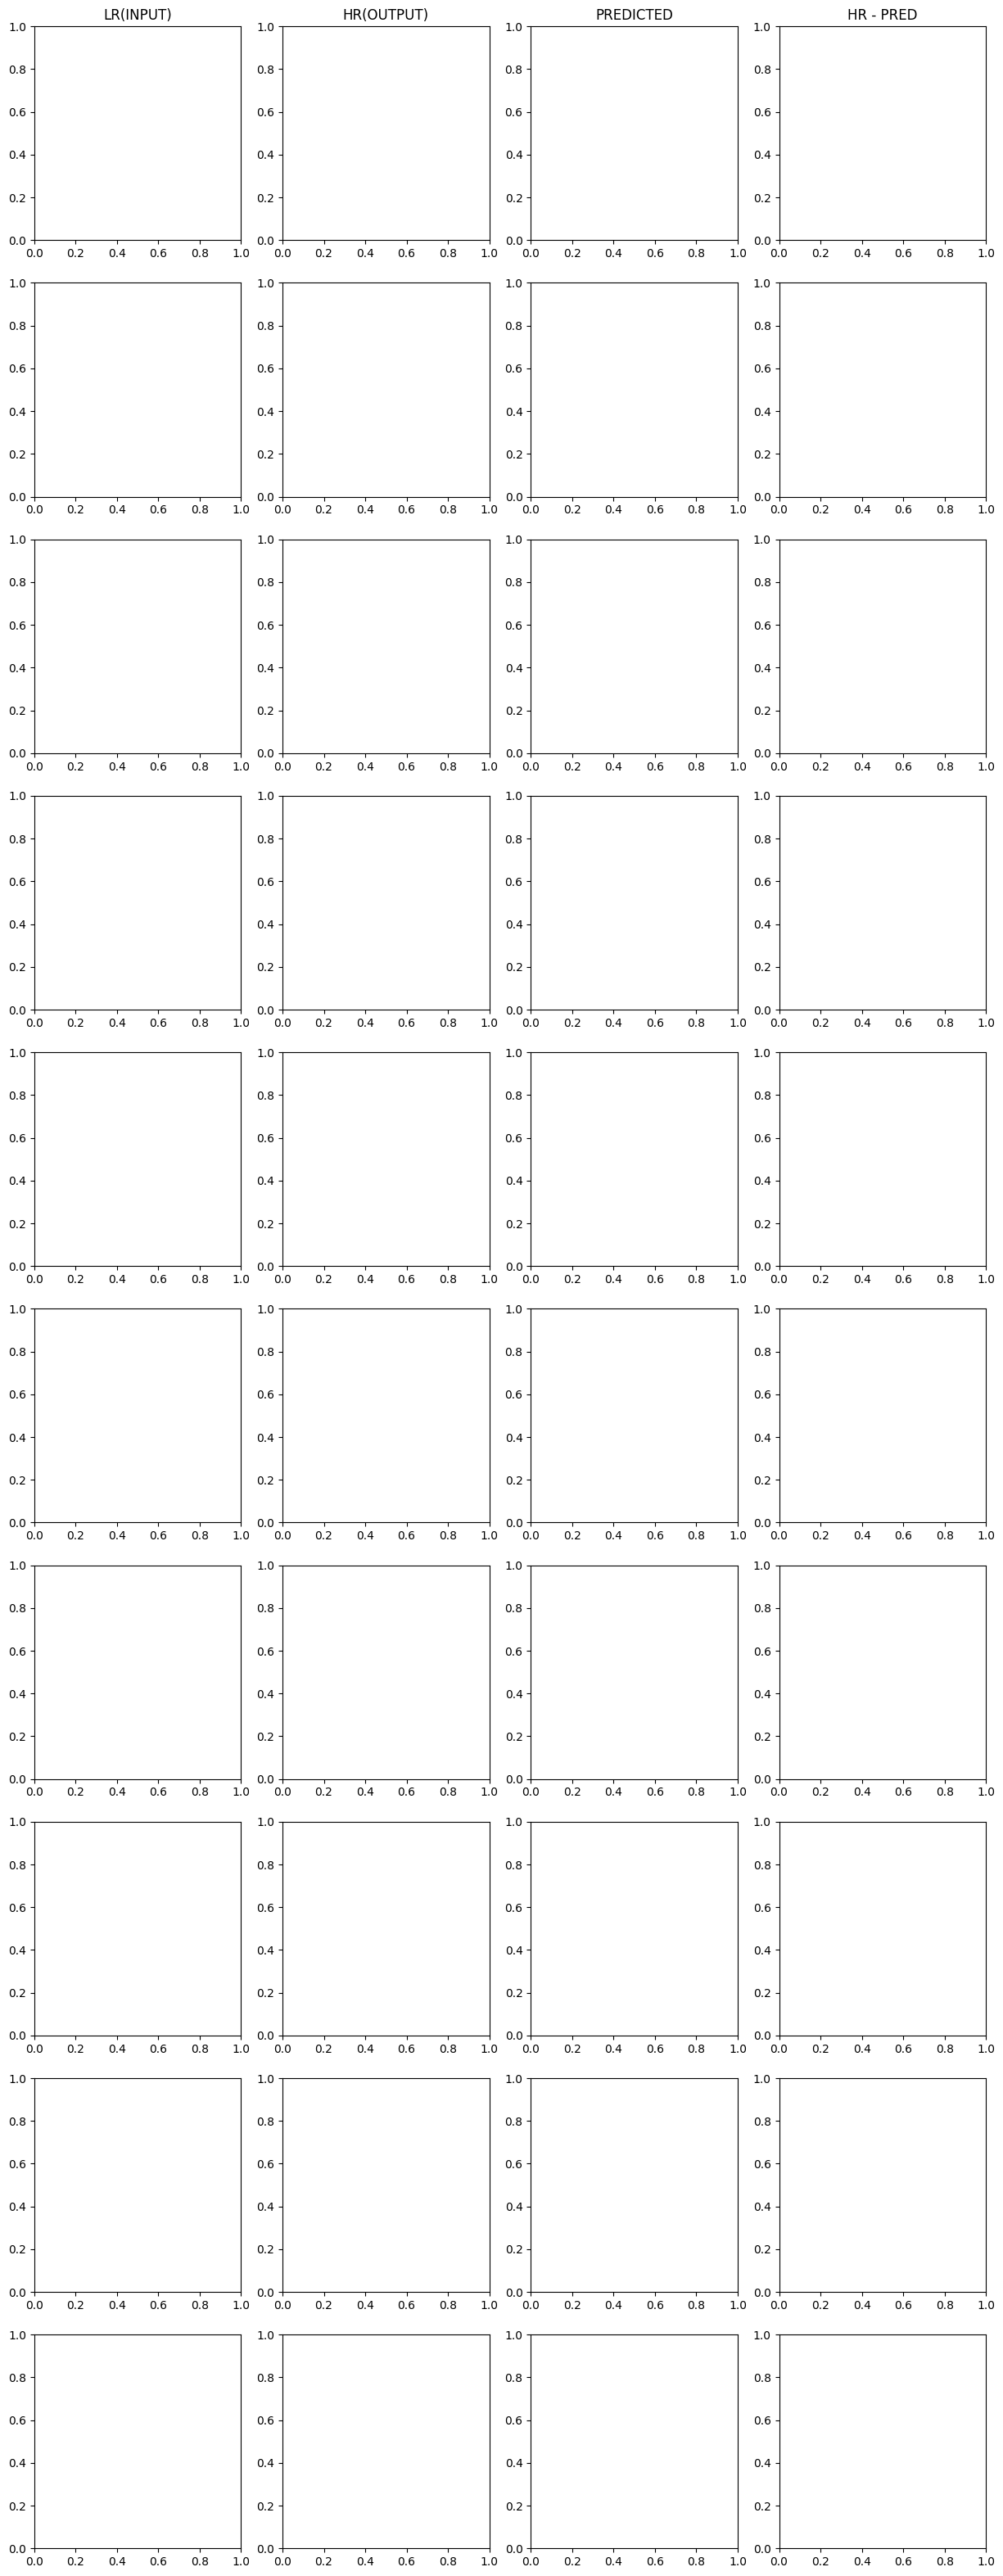

In [30]:
samples = 10
fig, ax = plt.subplots(samples,4)

# to change size of subplot's set height of each subplot as 8
fig.set_figheight(4*samples)
 
# set width of each subplot as 8
fig.set_figwidth(15)
ax[0][0].set_title("LR(INPUT)")
ax[0][1].set_title("HR(OUTPUT)")
ax[0][2].set_title("PREDICTED")
ax[0][3].set_title("HR - PRED")
for i in range(samples):
    lr,hr,size,rel_coor = next(iter(loader.training_data))
    
    lr_tensor = lr.squeeze().to('cuda').float()  # ranges from [0, 1]
    hr_tensor = hr.squeeze().to('cuda').float()  # ranges from [0, 1]
    # size = np.asarray(size)

    if(len(rel_coor) == 2):
        tv_tensor = rel_coor[1].squeeze().to('cuda').float()  
        rel_coor = rel_coor[0].squeeze().to('cuda').float()
    else:
        rel_coor = rel_coor.squeeze().to('cuda').float()
        
    idx = np.where(np.asarray(temp[0].squeeze().shape[1:-1]) == min(temp[0].squeeze().shape[1:-1]))[0][0]
    buf = {}
    
    lr_tensor = torch.permute(temp[0].squeeze(), (0,4,1,2,3)).to('cuda')
    pred = curr_model.forward(lr_tensor,temp[2][0],rel_coor)
    pred = torch.permute(pred, (0,2,3,4,1)).float()
    
#     ax[i][3].set_title(f"{temp[2]}")
    
    buf[2] = pred.cpu().detach().numpy()
    buf[3] = temp[1].squeeze() - buf[2]
    
    
    if idx == 0 :
        buf[0],buf[1] = temp[0].squeeze()[0,0,:,:,0],temp[1].squeeze()[0,0,:,:,0]
        buf[2],buf[3] = buf[2][0,0,:,:,0],buf[3][0,0,:,:,0]
    elif idx == 1:
        buf[0],buf[1] = temp[0].squeeze()[0,:,0,:,0],temp[1].squeeze()[0,:,0,:,0]
        buf[2],buf[3] = buf[2][0,:,0,:,0],buf[3][0,:,0,:,0]
    else:
        buf[0],buf[1] = temp[0].squeeze()[0,:,:,0,0],temp[1].squeeze()[0,:,:,0,0]
        buf[2],buf[3] = buf[2][0,:,:,0,0],buf[3][0,:,:,0,0]
        
    for j in range(4):
#         print(j)
        if(j == 3):
            im = ax[i][j].imshow(buf[j],cmap='jet')
        else:
            im = ax[i][j].imshow(buf[j])
        divider = make_axes_locatable(ax[i][j])
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(im, cax=cax, orientation='vertical')
        ax[i][j].tick_params(left = False, right = False , labelleft = False , 
            labelbottom = False, bottom = False) 
    
        

## FA

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 6 is not equal to len(dims) = 5

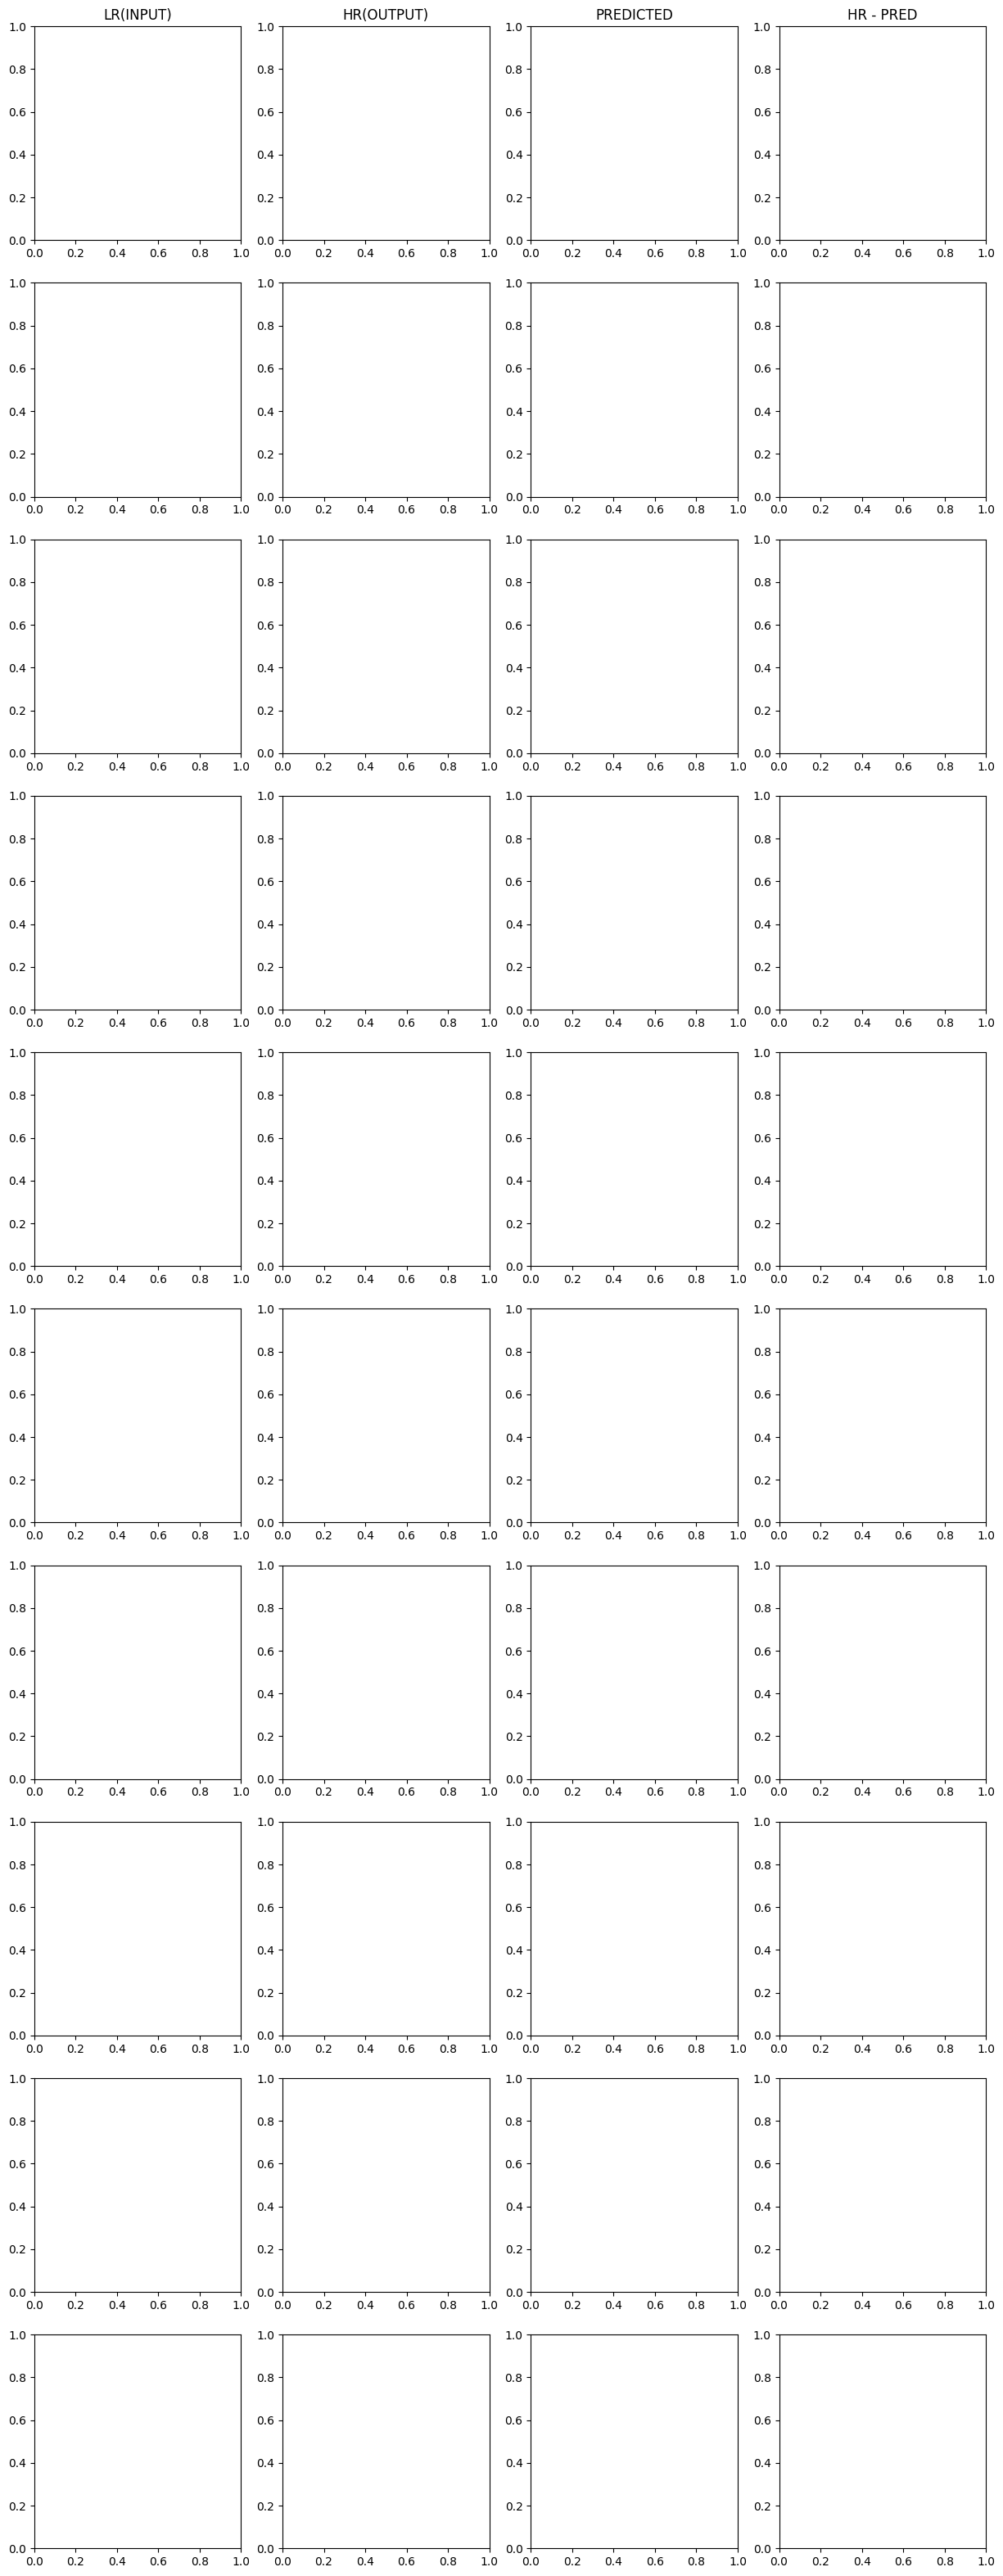

In [29]:
samples = 10
fig, ax = plt.subplots(samples,4)

# to change size of subplot's set height of each subplot as 8
fig.set_figheight(4*samples)
 
# set width of each subplot as 8
fig.set_figwidth(15)
ax[0][0].set_title("LR(INPUT)")
ax[0][1].set_title("HR(OUTPUT)")
ax[0][2].set_title("PREDICTED")
ax[0][3].set_title("HR - PRED")
for i in range(samples):
    temp = next(iter(loader.training_data))
    buf = {}
    buf[0] = temp[0][0,:,:,0,1]
    buf[1] = temp[1][0,:,:,0,1]
    
    lr_tensor = torch.permute(temp[0], (0,4,1,2,3)).to('cuda')
    pred = curr_model.forward(lr_tensor,temp[2])
    pred = torch.permute(pred, (0,2,3,4,1)).float()
    
    ax[i][3].set_title(f"{temp[2]}")
    
    buf[2] = pred[0,:,:,0,1].cpu().detach().numpy()
    buf[3] = temp[1][0,:,:,0,1] - buf[2]
    
    for j in range(4):
        if(j == 3):
            im = ax[i][j].imshow(buf[j],cmap='jet')
        else:
            im = ax[i][j].imshow(buf[j])
        divider = make_axes_locatable(ax[i][j])
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(im, cax=cax, orientation='vertical')
        ax[i][j].tick_params(left = False, right = False , labelleft = False , 
            labelbottom = False, bottom = False) 
    
        

In [21]:
temp[0].shape

torch.Size([1, 32, 32, 8, 7])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

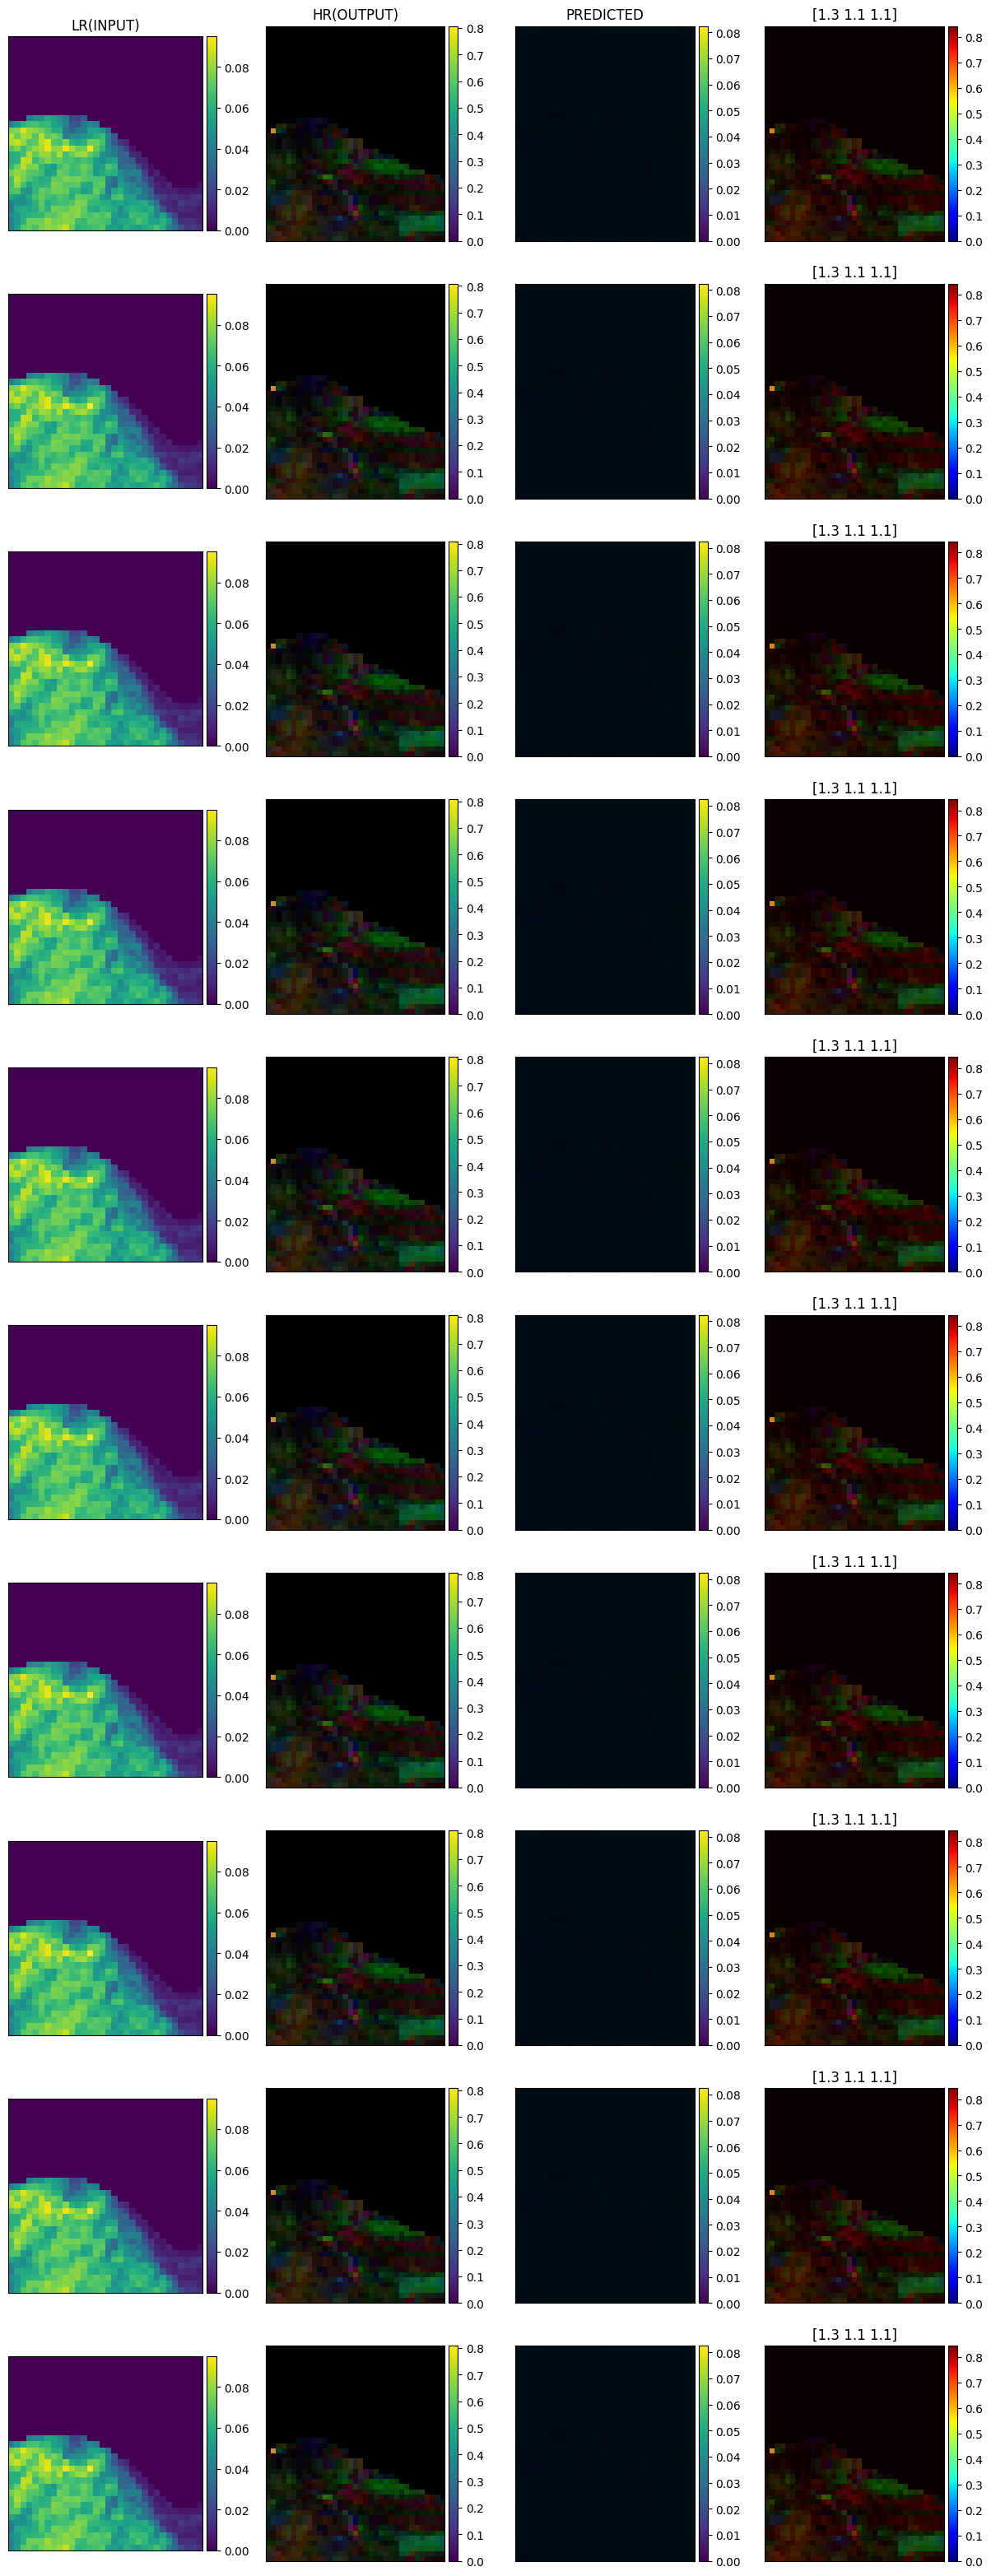

In [22]:
samples = 10
fig, ax = plt.subplots(samples,4)

# to change size of subplot's set height of each subplot as 8
fig.set_figheight(4*samples)
 
# set width of each subplot as 8
fig.set_figwidth(15)
ax[0][0].set_title("LR(INPUT)")
ax[0][1].set_title("HR(OUTPUT)")
ax[0][2].set_title("PREDICTED")
ax[0][3].set_title("HR - PRED")
for i in range(samples):
    temp = next(iter(loader.training_data))
    buf = {}
    buf[0] = temp[0][0,:,:,0,1]
    buf[1] = temp[1][0,:,:,0,2:]
    
    lr_tensor = torch.permute(temp[0], (0,4,1,2,3)).to('cuda')
    pred = curr_model.forward(lr_tensor,temp[2])
    pred = torch.permute(pred, (0,2,3,4,1)).float()
    
    ax[i][3].set_title(f"{temp[2]}")
    
    buf[2] = pred[0,:,:,0,2:].cpu().detach().numpy()
    buf[3] = temp[1][0,:,:,0,2:] - buf[2]
    
    for j in range(4):
        if(j == 3):
            im = ax[i][j].imshow(buf[j],cmap='jet')
        else:
            im = ax[i][j].imshow(buf[j])
        divider = make_axes_locatable(ax[i][j])
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(im, cax=cax, orientation='vertical')
        ax[i][j].tick_params(left = False, right = False , labelleft = False , 
            labelbottom = False, bottom = False) 
    
        

In [105]:
def recon(lr_tensor,hr_tensor,pnts):
    num_blk = lr_tensor.shape[0]
    vol = torch.empty(size=hr_tensor.shape)
    with torch.no_grad():
        for ii in range(num_blk):
            tm = lr_tensor[ii,...]
            tm = tm.unsqueeze(0)
            pred = curr_model.forward(tm,scale)
            pred = torch.permute(pred, (0,2,3,4,1)).float()
            vol[pnts[ii][0]:pnts[ii][1]+1,pnts[ii][2]:pnts[ii][3]+1,pnts[ii][4]:pnts[ii][5]+1,...] = pred[0,...]
    return vol

In [90]:
for iteration, (lr_tensor, hr_tensor,pnts,scale) in enumerate(loader.testing_data, 1):
    lr_tensor = lr_tensor.to('cuda')
    hr_tensor = hr_tensor.to('cuda')
    lr_tensor = torch.permute(lr_tensor, (0,4,1,2,3))
    
    vol = recon(lr_tensor,hr_tensor,pnts)

            
    break

In [91]:
vol.shape

torch.Size([232, 261, 232, 5])

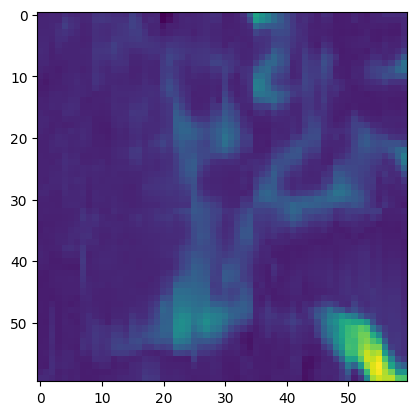

In [22]:
plt.imshow(vol[80,:,:,0][40:100,40:100])

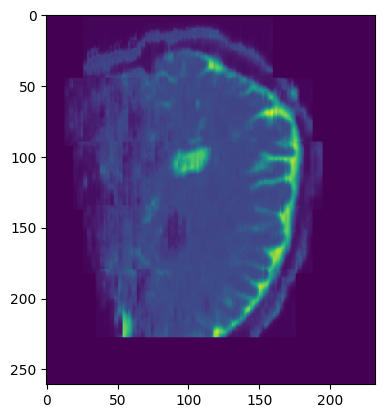

In [92]:
plt.imshow(vol[80,:,:,0])

In [67]:
scale = (1.2,1.2,1.2)
temp = loaded['172130']['vol0']
temp = temp[np.newaxis,...]
temp = torch.from_numpy(temp)

temp = torch.permute(temp, (0,4,1,2,3))
temp = temp.to('cuda')

In [68]:
temp.shape

torch.Size([1, 7, 145, 174, 145])

In [69]:
scale

(1.2, 1.2, 1.2)

In [73]:
loaded_gt['172130']['ADC'].shape

(173, 207, 173, 1)

In [74]:
tmp = temp[:,:,20:84,20:84,60:64]

In [75]:
tmp.shape

torch.Size([1, 7, 64, 64, 4])

In [76]:
scale

(1.2, 1.2, 1.2)

In [82]:
o = curr_model.forward(tmp,scale)
o = torch.permute(o, (0,2,3,4,1)).float()

In [83]:
o.shape

torch.Size([1, 77, 77, 5, 5])

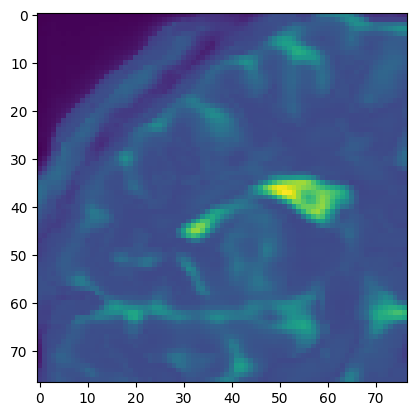

In [84]:
plt.imshow(o[0,:,:,2,0].cpu().detach().numpy())

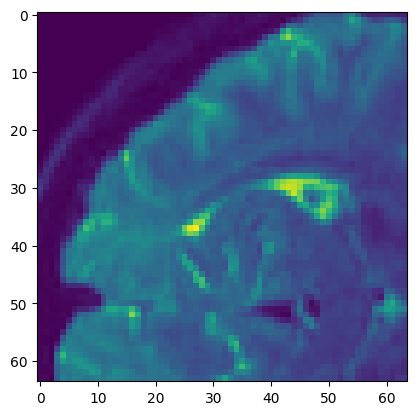

In [88]:
plt.imshow(temp[0,0,20:84,20:84,62].cpu().detach().numpy())

In [86]:
temp[0,0,20:84,20:84,60:64].shape

torch.Size([64, 64, 4])

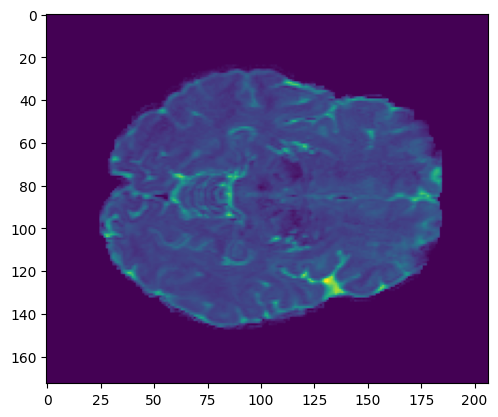

In [80]:
plt.imshow(loaded_gt['172130']['ADC'][:,:,62:63,0])


In [47]:
loaded['172130']

{'vol0': array([[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],
 
         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],
 
         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
     